In [1]:
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import (accuracy_score,
                             classification_report, 
                            confusion_matrix,
                            ConfusionMatrixDisplay,
                            f1_score)

In [2]:
inpDir = Path('..') / '..' / 'input'

outDir = Path('..') / '..' / 'input'


RANDOM_STATE = 24

rng = np.random.default_rng(seed = RANDOM_STATE)

NOISE = 0.2
EPOCHS = 50000
ALPHA = 0.1
N_SAMPLE = 1000
TEST_SIZE = 0.2

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
def fn_plot_decision_boundary(model: dict,
                              X_tr: np.ndarray,
                              y_tr: np.ndarray,
                              X_ts: np.ndarray,
                              y_ts: np.ndarray):
    """
    model : trained nn network model
    X_tr : train feature matrix
    y_tr : train labels
    X_ts : test feature matrix
    y_ts : test labels
    """
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    dm = 0.05
    padding = 2 * dm
    
    # Use training set for boundary range
    x_min, x_max = X_tr[:, 0].min() - padding, X_tr[:, 0].max() + padding
    y_min, y_max = X_tr[:, 1].min() - padding, X_tr[:, 1].max() + padding
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))
    
    # Predict over grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = fn_predict(model, grid_points).reshape(xx.shape)
    
    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
    
    # Training points
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr.ravel(), s=20, edgecolor='k', cmap=plt.cm.bwr, label="Train")
    
    # Test points
    ax.scatter(X_ts[:, 0], X_ts[:, 1], c=y_ts.ravel(), s=20, edgecolor='k', cmap=plt.cm.coolwarm, marker='x', label="Test")
    
    ax.set_title('Decision Boundary')
    ax.set_xlabel('A')
    ax.set_ylabel('B')
    ax.legend()
    plt.show()

In [4]:
X, y = datasets.make_moons(n_samples=N_SAMPLE, 
                           noise=NOISE,
                           shuffle=True, 
                           random_state=RANDOM_STATE)
X[:5], y[:5]

(array([[ 0.90633951,  0.90267624],
        [-1.11536828,  0.75579289],
        [ 1.88769158,  0.4175967 ],
        [-0.93345034, -0.02299851],
        [-0.96872877,  0.06396285]]),
 array([0, 0, 1, 0, 0]))

In [5]:
y=pd.get_dummies(y).to_numpy()
y.shape

(1000, 2)

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,random_state=RANDOM_STATE,test_size=TEST_SIZE)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((800, 2), (200, 2), (800, 2), (200, 2))

In [7]:
def fn_softmax(z):
    exp_sc=np.exp(z)
    return exp_sc/np.sum(exp_sc,axis=1,keepdims=True)

In [8]:
sm = fn_softmax(np.array([[8,5,0],[-10,0.,10.]]))
sm

array([[9.52269826e-01, 4.74107229e-02, 3.19450938e-04],
       [2.06106005e-09, 4.53978686e-05, 9.99954600e-01]])

### Tanh Activation Functions

In [9]:
def fn_activ(z):
    return np.tanh(z)
def fn_activ_prime(z):
    return 1-np.tanh(z)**2
    

In [10]:
fn_activ(np.array([[-1,0,1],[-np.inf,0.,np.inf]]))

array([[-0.76159416,  0.        ,  0.76159416],
       [-1.        ,  0.        ,  1.        ]])

In [11]:
np.tanh(0.5),(1-np.power(np.tanh(0.5),2)),fn_activ_prime(0.5)

(np.float64(0.46211715726000974),
 np.float64(0.7864477329659274),
 np.float64(0.7864477329659274))

## Back propogation

In [12]:
def fn_predict(model,X_p):
    W1,W2,b1,b2=model['W1'],model['W2'],model['b1'],model['b2']    
    z1=X_p.dot(W1)+b1
    a1=fn_activ(z1)

    z2=a1.dot(W2)+b2
    a2=fn_softmax(z2)
    return np.argmax(a2,axis=1)

In [13]:
def fn_calculate_loss(model,X_l,y_l):
    W1,W2,b1,b2=model['W1'],model['W2'],model['b1'],model['b2']
    m=X_l.shape[0]
    
    z1=X_l.dot(W1)+b1
    a1=fn_activ(z1)

    z2=a1.dot(W2)+b2
    a2=fn_softmax(z2)

    data_loss=-np.sum(y_l*np.log(a2))
    return data_loss/m

In [14]:
 def fn_build_model(nn_hdim,X,y,n_epochs=EPOCHS,alpha=ALPHA):
    m,nn_input_dim=X.shape
    nn_output_dim=y.shape[1]
    W1=rng.random((nn_input_dim,nn_hdim),dtype=np.float32) / np.sqrt(nn_input_dim)
    W2=rng.random((nn_hdim,nn_output_dim),dtype=np.float32) / np.sqrt(nn_hdim)

    b1=np.zeros((1,nn_hdim),dtype=np.float32)
    b2=np.zeros((1,nn_output_dim),dtype=np.float32)

    curr_loss=0
    loss, epoch=[],[]

    for i in range(n_epochs):
        ### Forward Propagation 
        z1=X.dot(W1)+b1
        a1=fn_activ(z1)

        z2=a1.dot(W2)+b2
        a2=fn_softmax(z2)
       
        ### Back Propagation
        dz2=a2-y
        assert(z2.shape==dz2.shape),f'Shape Mismatch z2{z2.shape} and {dz2.shape}'
        
        dW2=(a1.T).dot(dz2)
        assert(W2.shape==dW2.shape),f'SM W2 {W2.shape} and {dW2.shape}'

        db2=np.sum(dz2,axis=0,keepdims=True)
        assert(b2.shape==db2.shape),f'SM b2 {b2.shape} and {db2.shape}'

        da1=dz2.dot(W2.T)
        assert(a1.shape==da1.shape),f'SM a1 {a1.shape} and {da1.shape}'

        dz1=da1*fn_activ_prime(z1)
        assert(z1.shape==dz1.shape),f'SM z1 {z1.shape} and {dz1.shape}'

        dW1=(X.T).dot(dz1)
        assert(W1.shape==dW1.shape),f'SM W1 {W1.shape} and {dW1.shape}'

        db1=np.sum(dz1,axis=0,keepdims=True)
        assert(b1.shape==db1.shape),f'SM b1 {b1.shape} and {db1.shape}'

        #gradient update
        W1=W1-alpha*dW1/m#element wise multiplication
        W2=W2-alpha*dW2/m
        b1=b1-alpha*db1/m
        b2=b2-alpha*db2/m
        
        model={"W1":W1,"b1":b1,"W2":W2,"b2":b2}

        if i%100==0:
            curr_loss=fn_calculate_loss(model,X,y)
            loss.append(curr_loss)
            epoch.append(i)

            if i%1000==0:
                print(f'Loss after epoch {i:>5d}: {curr_loss:.5f}')
    return model, loss, epoch

In [15]:
# y_train=y_train.reshape(-1,1)
# y_train.shape

In [16]:
nn_hdim=4
model,loss,epoch=fn_build_model(nn_hdim,X_train,y_train,n_epochs=EPOCHS,alpha=ALPHA)
model

Loss after epoch     0: 0.68079
Loss after epoch  1000: 0.30290
Loss after epoch  2000: 0.30220
Loss after epoch  3000: 0.30176
Loss after epoch  4000: 0.30145
Loss after epoch  5000: 0.30123
Loss after epoch  6000: 0.30105
Loss after epoch  7000: 0.30090
Loss after epoch  8000: 0.30078
Loss after epoch  9000: 0.30067
Loss after epoch 10000: 0.30057
Loss after epoch 11000: 0.30047
Loss after epoch 12000: 0.30037
Loss after epoch 13000: 0.30026
Loss after epoch 14000: 0.30013
Loss after epoch 15000: 0.29998
Loss after epoch 16000: 0.29977
Loss after epoch 17000: 0.29948
Loss after epoch 18000: 0.29905
Loss after epoch 19000: 0.29809
Loss after epoch 20000: 0.14501
Loss after epoch 21000: 0.08935
Loss after epoch 22000: 0.07904
Loss after epoch 23000: 0.07511
Loss after epoch 24000: 0.07303
Loss after epoch 25000: 0.07167
Loss after epoch 26000: 0.07069
Loss after epoch 27000: 0.06992
Loss after epoch 28000: 0.06932
Loss after epoch 29000: 0.06883
Loss after epoch 30000: 0.06844
Loss aft

{'W1': array([[-4.43655315,  1.96812669,  3.03247052, -1.50964047],
        [ 2.01000862,  1.52921091, -1.12388269, -0.21211118]]),
 'b1': array([[-2.25475526, -1.31223647, -3.9083801 , -1.41705794]]),
 'W2': array([[ 3.3557596 , -2.87011121],
        [ 4.79602611, -4.22129065],
        [-3.73929572,  4.46232691],
        [ 1.4882626 , -1.27783066]]),
 'b2': array([[ 0.48284356, -0.48284356]])}

<Axes: xlabel='epoch'>

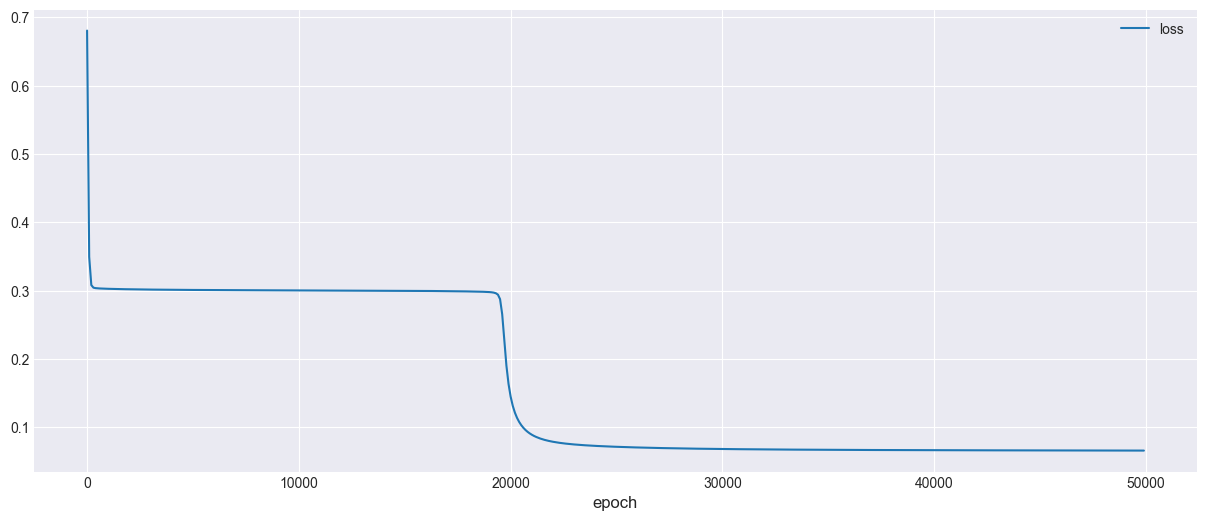

In [17]:
loss_hist={}
loss_hist['loss']=loss
loss_hist['epoch']=epoch
pd.DataFrame(loss_hist).plot(x='epoch',y='loss')

In [18]:
y_pred = fn_predict(model,X_train)
print('Accuracy on train: ',accuracy_score(y_train.argmax(axis=1),y_pred))

Accuracy on train:  0.975


In [19]:
cm=confusion_matrix(y_train.argmax(axis=1),y_pred)
cm

array([[390,  10],
       [ 10, 390]])

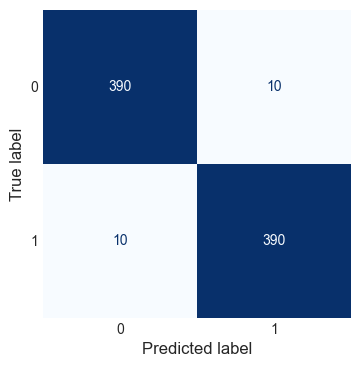

In [20]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
fig,ax=plt.subplots(figsize=(4,4))
disp.plot(ax=ax,cmap='Blues',colorbar=False)
ax.grid()

In [21]:
f1_score(y_train.argmax(axis=1),y_pred,average='weighted')

0.975

In [22]:
y_pred = fn_predict(model,X_test)
print('Accuracy on test data', accuracy_score(y_test.argmax(axis=1),y_pred))

Accuracy on test data 0.985


C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_13780\3855278400.py:37: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_ts[:, 0], X_ts[:, 1], c=y_ts.ravel(), s=20, edgecolor='k', cmap=plt.cm.coolwarm, marker='x', label="Test")


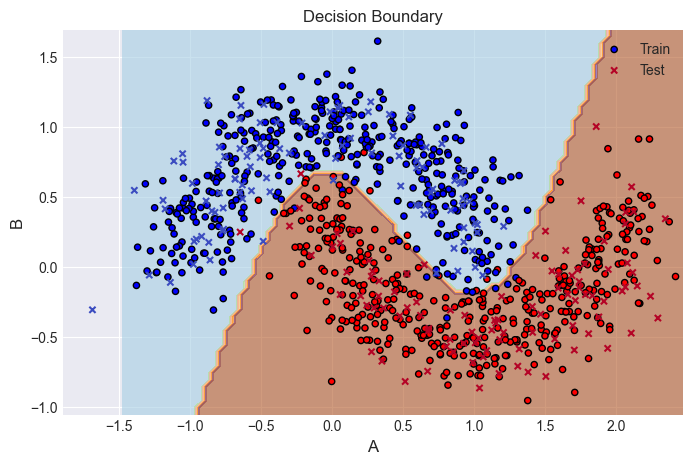

In [23]:
fn_plot_decision_boundary(model, X_train, y_train.argmax(axis=1), X_test, y_test.argmax(axis=1))